In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted - Raw_Mixed_Split ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted - Raw_Mixed_Split ready!


In [ ]:
# MODEL2 MIXED DATASET - CLEAN NOTEBOOK
import os, tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler, CSVLogger, ModelCheckpoint
from google.colab import drive

# MODEL2 SPECIFIC (with prefix)
CHECKPOINT_DIR2 = '/content/drive/MyDrive/model2_mixedDataset_Model2_Checkpoints_UPDATED'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'

# CREATE FOLDER if not exists
os.makedirs(CHECKPOINT_DIR2, exist_ok=True)
drive.mount('/content/drive')

print(f"✅ Model2 folder created: {CHECKPOINT_DIR2}")
print(f"📁 Dataset: {DATA_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model2 folder created: /content/drive/MyDrive/model2_mixedDataset_Model2_Checkpoints_UPDATED
📁 Dataset: /content/drive/MyDrive/Raw_Mixed_Split


In [ ]:
# VERIFY DATASET INTACT - Raw_Mixed_Split
import os

DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'

print("=== DATASET CHECK ===")
for split in ['train', 'val', 'test']:
    split_path = os.path.join(DATA_DIR, split)
    if os.path.exists(split_path):
        total = 0
        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            if os.path.isdir(class_path):
                count = len(os.listdir(class_path))
                total += count
                print(f"  {split}/{class_name}: {count}")
        print(f"  {split} TOTAL: {total}")
    else:
        print(f"❌ {split_path} MISSING")

print(f"\nExpected: Train~8016, Val~1002, Test=2004")

=== DATASET CHECK ===
  train/fire: 8169
  train/nofire: 7852
  train TOTAL: 16021
  val/fire: 1021
  val/nofire: 981
  val TOTAL: 2002
  test/fire: 1022
  test/nofire: 982
  test TOTAL: 2004

Expected: Train~8016, Val~1002, Test=2004


In [ ]:
# BLOCK 1: MIXED DATASET GENERATORS (224x224, 2-class)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'

# Simple rescaling (no augmentation for baseline)
datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_gen = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'  # 2-class
)

val_gen = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("✅ Generators Ready!")
print(f"Train: {train_gen.samples}, Val: {val_gen.samples}, Test: {test_gen.samples}")
print(f"Classes: {train_gen.class_indices}")

Found 16021 images belonging to 2 classes.
Found 2002 images belonging to 2 classes.
Found 2004 images belonging to 2 classes.
✅ Generators Ready!
Train: 16021, Val: 2002, Test: 2004
Classes: {'fire': 0, 'nofire': 1}


In [ ]:
# BLOCK 1: EXACT Model1 generators (augmented)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# EXACT Model1 - Augmented train
train_datagen = ImageDataGenerator(
    rescale=1./255.0,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Plain val
val_datagen = ImageDataGenerator(rescale=1./255.0)

train_gen = train_datagen.flow_from_directory(f'{DATA_DIR}/train', target_size=IMG_SIZE,
                                             batch_size=BATCH_SIZE, class_mode='binary')
val_gen = val_datagen.flow_from_directory(f'{DATA_DIR}/val', target_size=IMG_SIZE,
                                         batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

print(" Model2 generators = EXACT Model1")

Found 16021 images belonging to 2 classes.
Found 2002 images belonging to 2 classes.
 Model2 generators = EXACT Model1


In [ ]:
# FIX MODEL OUTPUT (1 neuron for binary)
def build_model2_mixed_fixed(input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(inputs)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(256, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = MaxPooling2D(2,2)(x)
    x = Conv2D(128, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3,3), padding='valid', activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='selu')(x); x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)  # ← 1 OUTPUT
    return Model(inputs, outputs)

# Rebuild + compile
model2_mixed = build_model2_mixed_fixed()
model2_mixed.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model2_mixed.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 222, 222, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 109, 109, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 109, 109, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 52, 52, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 52, 52, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 22, 22, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 746,433 (2.85 MB)

 Trainable params: 745,153 (2.84 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
# BLOCK 3: TRAINING CONFIG (exact Model1_Mixed pattern)
import math
from tensorflow.keras.callbacks import LearningRateScheduler, CSVLogger

STEPS_PER_EPOCH = math.ceil(16021 / 32)  # 501
VAL_STEPS = math.ceil(2002 / 32)         # 63

def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

callbacks = [
    LearningRateScheduler(lr_scheduler),
    CSVLogger('model2_mixed_log.csv', append=True)
]

print(f"Config: {STEPS_PER_EPOCH} steps/epoch, {VAL_STEPS} val steps")
print("Callbacks: LR scheduler + CSV log")

Config: 501 steps/epoch, 63 val steps
Callbacks: LR scheduler + CSV log


In [ ]:
# BLOCK 3: TRAINING + CHECKPOINT (OLD BLOCK)
from tensorflow.keras.callbacks import LearningRateScheduler, CSVLogger, ModelCheckpoint

def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5


callbacks = [
    LearningRateScheduler(lr_scheduler),
    CSVLogger('/content/drive/MyDrive/model2_mixed_log.csv', append=True),
    ModelCheckpoint(
        '/content/drive/MyDrive/Model2_Mixed_Checkpoint_UPDATED.keras',
        save_best_only=False,  # Every epoch
        save_weights_only=False,
        verbose=1
    )
]

print(" Starting 40 epochs...")
history = model2_mixed.fit(
    train_gen,
    steps_per_epoch=501,
    epochs=40,
    validation_data=val_gen,
    validation_steps=63,
    callbacks=callbacks
)

 Starting 40 epochs...
Epoch 1/40
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9221 - loss: 0.1982
Epoch 1: saving model to /content/drive/MyDrive/Model2_Mixed_Checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Model2_Mixed_Checkpoint.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 4411s 9s/step - accuracy: 0.9450 - loss: 0.1541 - val_accuracy: 0.5889 - val_loss: 1.1872 - learning_rate: 0.0010
Epoch 2/40
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.9633 - loss: 0.1068
Epoch 2: saving model to /content/drive/MyDrive/Model2_Mixed_Checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Model2_Mixed_Checkpoint.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 461s 919ms/step - accuracy: 0.9657 - loss: 0.1045 - val_accuracy: 0.9496 - val_loss: 0.1772 - learning_rate: 0.0010
Epoch 3/40
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - accuracy: 0.9676 - loss: 0.0921
Epoch 3: saving model to /content/drive/MyDrive/Model2_Mixed_Checkpoint.keras

Epoch 3: finished

In [ ]:
#( BLOCK3 - NEW BLOCK)
import os
from tensorflow.keras.callbacks import LearningRateScheduler, CSVLogger, ModelCheckpoint

# 1. DEFINE THE DIRECTORY
MODEL3_DIR = '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED'
os.makedirs(MODEL3_DIR, exist_ok=True)

# 2. DEFINE THE PATHS INSIDE THAT FOLDER
# This saves a new file for every epoch: model3_ep_01.keras, etc.
checkpoint_path = os.path.join(MODEL3_DIR, 'model3_ep_{epoch:02d}.keras')
log_path = os.path.join(MODEL3_DIR, 'model3_training_log_UPDATED.csv')

# 3. SETUP CALLBACKS
def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

callbacks = [
    LearningRateScheduler(lr_scheduler),
    CSVLogger(log_path, append=True),
    ModelCheckpoint(
        checkpoint_path,
        save_best_only=False,
        verbose=1
    )
]

print(f"✅ Folder Ready: {MODEL3_DIR}")
print(f"📝 Log will save to: {log_path}")
print("🚀 Starting 40 epochs...")

# 4. START TRAINING
history = model2_mixed.fit(
    train_gen,
    steps_per_epoch=501,
    epochs=40,
    validation_data=val_gen,
    validation_steps=63,
    callbacks=callbacks
)

✅ Folder Ready: /content/drive/MyDrive/Model3_Mixed_Training_UPDATED
📝 Log will save to: /content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_training_log_UPDATED.csv
🚀 Starting 40 epochs...


NameError: name 'model2_mixed' is not defined

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
!rm -rf /content/drive  # Clear stale mountpoint
print("✅ Unmounted & cleaned")

Drive not mounted, so nothing to flush and unmount.
✅ Unmounted & cleaned


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("✅ Drive REMOUNTED - Raw_Mixed_Split ready!")

Mounted at /content/drive
✅ Drive REMOUNTED - Raw_Mixed_Split ready!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# EXACT Model1 - Augmented train
train_datagen = ImageDataGenerator(
    rescale=1./255.0,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Plain val
val_datagen = ImageDataGenerator(rescale=1./255.0)

train_gen = train_datagen.flow_from_directory(f'{DATA_DIR}/train', target_size=IMG_SIZE,
                                             batch_size=BATCH_SIZE, class_mode='binary')
val_gen = val_datagen.flow_from_directory(f'{DATA_DIR}/val', target_size=IMG_SIZE,
                                         batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

print("✅ Generators READY - train_gen, val_gen available")
print(f"Train: {train_gen.samples}, Val: {val_gen.samples}")

Found 16021 images belonging to 2 classes.
Found 2002 images belonging to 2 classes.
✅ Generators READY - train_gen, val_gen available
Train: 16021, Val: 2002


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import LearningRateScheduler, CSVLogger, ModelCheckpoint

# Paths (your exact setup)
MODEL3_DIR = '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED'
checkpoint_path = os.path.join(MODEL3_DIR, 'model3_ep_{epoch:02d}.keras')
log_path = os.path.join(MODEL3_DIR, 'model3_training_log_UPDATED.csv')

# Find latest epoch
#checkpoints = sorted([f for f in os.listdir(MODEL3_DIR) if f.startswith('model3_ep_')])
checkpoints = sorted(
    [f for f in os.listdir(MODEL3_DIR) if f.startswith('model3_ep_')],
    key=lambda x: int(x.split('_ep_')[1].split('.keras')[0])
)
latest_epoch = int(checkpoints[-1].split('_ep_')[1].split('.keras')[0])  # 17
print(f"✅ Resuming from epoch {latest_epoch} → {latest_epoch+1}/40")

# Load model
model2_mixed = load_model(os.path.join(MODEL3_DIR, f'model3_ep_{latest_epoch:02d}.keras'))
print("✅ Model LOADED")

# Same callbacks
def lr_scheduler(epoch):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    else: return 1e-5

callbacks = [
    LearningRateScheduler(lr_scheduler),
    CSVLogger(log_path, append=True),
    ModelCheckpoint(checkpoint_path, save_best_only=False, verbose=1)
]

# RESUME TRAINING
history = model2_mixed.fit(
    train_gen, steps_per_epoch=501,
    epochs=40, initial_epoch=latest_epoch,  # ← KEY: continues from 18
    validation_data=val_gen, validation_steps=63,
    callbacks=callbacks, verbose=1
)

✅ Resuming from epoch 17 → 18/40
✅ Model LOADED
Epoch 18/40
  2/501 ━━━━━━━━━━━━━━━━━━━━ 4:24:01 32s/step - accuracy: 0.9766 - loss: 0.0309

KeyboardInterrupt: 

In [ ]:
import os

# 1. Path to your Model 2 checkpoints
MODEL_DIR = '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED'

# 2. Get all files in that directory
all_files = os.listdir(MODEL_DIR)

# 3. Filter for just the .keras model files
checkpoints = sorted(
    [f for f in all_files if f.startswith('model3_ep_') and f.endswith('.keras')],
    key=lambda x: int(x.split('_ep_')[1].split('.keras')[0])
)

# 4. Display the names
print(f"📁 Content of: {MODEL_DIR}")
print("-" * 50)
for i, name in enumerate(checkpoints, 1):
    print(f"{i}. {name}")

# 5. Identify the absolute latest one
if checkpoints:
    print("-" * 50)
    print(f"✅ LATEST SAVED MODEL: {checkpoints[-1]}")
else:
    print("❌ No model files found yet.")

📁 Content of: /content/drive/MyDrive/Model3_Mixed_Training_UPDATED
--------------------------------------------------
1. model3_ep_01.keras
2. model3_ep_02.keras
3. model3_ep_03.keras
4. model3_ep_04.keras
5. model3_ep_05.keras
6. model3_ep_06.keras
7. model3_ep_07.keras
8. model3_ep_08.keras
9. model3_ep_09.keras
10. model3_ep_10.keras
11. model3_ep_11.keras
12. model3_ep_12.keras
13. model3_ep_13.keras
14. model3_ep_14.keras
15. model3_ep_15.keras
16. model3_ep_16.keras
17. model3_ep_17.keras
--------------------------------------------------
✅ LATEST SAVED MODEL: model3_ep_17.keras


In [ ]:
import os
import pandas as pd

# 1. Define the specific Model 2/3 directory
MODEL3_DIR = '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED'

print(f"🔍 Reading all files in: {MODEL3_DIR}\n")

if os.path.exists(MODEL3_DIR):
    all_files = os.listdir(MODEL3_DIR)

    # Sort files to make them readable
    all_files.sort()

    print(f"{'File Name':<45} | {'Type'}")
    print("-" * 60)

    for file in all_files:
        file_type = "Model (Keras)" if file.endswith('.keras') else "Log (CSV)" if file.endswith('.csv') else "Other"
        print(f"{file:<45} | {file_type}")

    # 2. Specifically read the content of the CSV log to see recorded progress
    log_file = os.path.join(MODEL3_DIR, 'model3_training_log_UPDATED.csv')
    if os.path.exists(log_file):
        print("\n📊 --- Preview of Training Log (CSV) ---")
        df = pd.read_csv(log_file)
        # Show first 3 and last 3 rows to verify the gap/progress
        display(df.iloc[[0, 1, 2, -3, -2, -1]])
    else:
        print("\n❌ Training log CSV not found in this folder.")
else:
    print("❌ Directory does not exist. Please check your Drive path.")

🔍 Reading all files in: /content/drive/MyDrive/Model3_Mixed_Training_UPDATED

File Name                                     | Type
------------------------------------------------------------
model3_ep_01.keras                            | Model (Keras)
model3_ep_02.keras                            | Model (Keras)
model3_ep_03.keras                            | Model (Keras)
model3_ep_04.keras                            | Model (Keras)
model3_ep_05.keras                            | Model (Keras)
model3_ep_06.keras                            | Model (Keras)
model3_ep_07.keras                            | Model (Keras)
model3_ep_08.keras                            | Model (Keras)
model3_ep_09.keras                            | Model (Keras)
model3_ep_10.keras                            | Model (Keras)
model3_ep_11.keras                            | Model (Keras)
model3_ep_12.keras                            | Model (Keras)
model3_ep_13.keras                            | Model (Keras)
mo

,epoch,accuracy,learning_rate,loss,val_accuracy,val_loss
0,0,0.954435,0.0010,0.135817,0.820180,0.489153
1,1,0.969540,0.0010,0.093196,0.729271,0.913524
2,2,0.972911,0.0010,0.082441,0.769730,1.603361
14,14,0.990512,0.0010,0.028486,0.980519,0.066978
15,15,0.992447,0.0001,0.023572,0.995005,0.016923
16,16,0.993509,0.0001,0.019750,0.994006,0.018695


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

# 1. SET PATHS
MODEL3_DIR = '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'
LOG_FILE = os.path.join(MODEL3_DIR, 'model3_training_log_UPDATED.csv')

# 2. LOAD THE LATEST SAVED MODEL (Epoch 17)
model_path = os.path.join(MODEL3_DIR, 'model3_ep_17.keras')
model = load_model(model_path)
print(f"✅ Model Loaded: model3_ep_17.keras")

# 3. SETUP TEST GENERATOR (Same as Model 1)
test_datagen = ImageDataGenerator(rescale=1./255.0)
test_gen = test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# 4. PREDICT ON TEST SET (2,004 images)
print("📊 Evaluating on Test Set...")
y_true = test_gen.classes
preds = model.predict(test_gen, verbose=1)
y_pred = (preds > 0.5).astype(int).flatten()

# 5. CALCULATE METRICS
test_acc = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred)
test_rec = recall_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

# 6. EXTRACT STATS FROM THE LOG CSV
df_log = pd.read_csv(LOG_FILE)
train_final = df_log['accuracy'].iloc[-1]
val_final = df_log['val_accuracy'].iloc[-1]
val_peak = df_log['val_accuracy'].max()

# 7. CREATE SUMMARY TABLE (Exact Model 1 Format)
summary_data = {
    "Metric": ["Train_Final", "Val_Final", "Val_Peak", "Test_Acc", "Test_Prec", "Test_Rec"],
    "Value": [
        round(train_final, 4),
        round(val_final, 4),
        round(val_peak, 4),
        round(test_acc, 4),
        round(test_prec, 4),
        round(test_rec, 4)
    ]
}
summary_df = pd.DataFrame(summary_data)

print("\n" + "="*40)
print("      FINAL SUMMARY TABLE (MODEL 2)")
print("="*40)
print(summary_df)
print(f"\nConfusion Matrix:\n{cm}")
print("="*40)

# 8. SAVE FILES (Just like Model 1)
summary_df.to_csv(os.path.join(MODEL3_DIR, 'model2_complete_summary.csv'), index=False)
with open(os.path.join(MODEL3_DIR, 'model2_summary.tex'), 'w') as f:
    f.write(summary_df.to_latex(index=False))

print(f"\n✅ Files Saved Successfully in: {MODEL3_DIR}")

✅ Model Loaded: model3_ep_17.keras
Found 2004 images belonging to 2 classes.
📊 Evaluating on Test Set...
63/63 ━━━━━━━━━━━━━━━━━━━━ 385s 6s/step

      FINAL SUMMARY TABLE (MODEL 2)
        Metric   Value
0  Train_Final  0.9935
1    Val_Final  0.9940
2     Val_Peak  0.9950
3     Test_Acc  0.9980
4    Test_Prec  1.0000
5     Test_Rec  0.9959

Confusion Matrix:
[[1022    0]
 [   4  978]]

✅ Files Saved Successfully in: /content/drive/MyDrive/Model3_Mixed_Training_UPDATED


Found 2004 images belonging to 2 classes.

📊 Evaluating Model 2 (model3_ep_17.keras)...
63/63 ━━━━━━━━━━━━━━━━━━━━ 250s 4s/step

             MODEL 2 FINAL SUMMARY
Model 2 reached a test accuracy of 99.80%,
with a precision of 100.00% and recall of 99.59%.
Training concluded at epoch 17 (saturation observed around epoch 16),
with a final training accuracy of 99.35%
and validation accuracy of 99.40%.
Out of 2004 test samples, the model produced 4 misclassifications:
0 false positives and 4 false negatives.


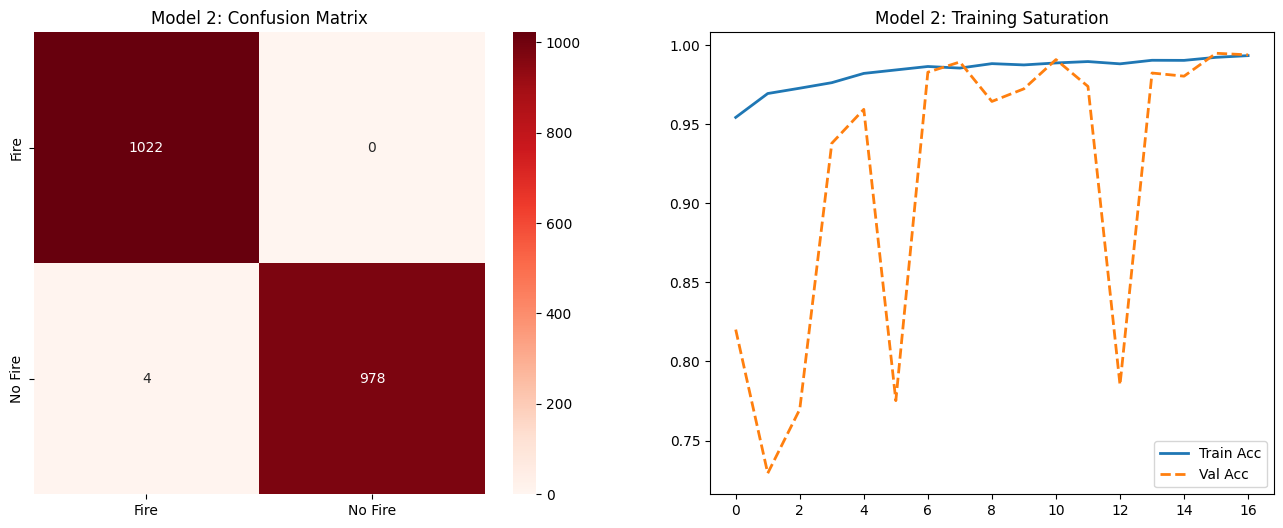

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score

# --- 1. CONFIGURATION ---
MODEL_DIR = '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'
LOG_FILE = os.path.join(MODEL_DIR, 'model3_training_log_UPDATED.csv')

# Automatically find latest model
checkpoints = sorted([f for f in os.listdir(MODEL_DIR) if f.startswith('model3_ep_') and f.endswith('.keras')],
                     key=lambda x: int(x.split('_ep_')[1].split('.keras')[0]))
LATEST_MODEL = os.path.join(MODEL_DIR, checkpoints[-1])

# --- 2. LOAD DATA & MODEL ---
test_gen = ImageDataGenerator(rescale=1./255.0).flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

model2 = load_model(LATEST_MODEL)
history_df = pd.read_csv(LOG_FILE)

# --- 3. EVALUATION ---
print(f"\n📊 Evaluating Model 2 ({checkpoints[-1]})...")
y_true = test_gen.classes
preds_prob = model2.predict(test_gen, verbose=1).flatten()
y_pred = (preds_prob > 0.5).astype(int)

# Calculate Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Identify Saturation
peak_val_acc = history_df['val_accuracy'].max()
peak_epoch = history_df['val_accuracy'].idxmax() + 1

# --- 4. PRINT FORMATTED SUMMARY (Like Model 1) ---
print("\n" + "="*50)
print("             MODEL 2 FINAL SUMMARY")
print("="*50)
print(f"Model 2 reached a test accuracy of {acc*100:.2f}%,")
print(f"with a precision of {prec*100:.2f}% and recall of {rec*100:.2f}%.")
print(f"Training concluded at epoch {len(history_df)} (saturation observed around epoch {peak_epoch}),")
print(f"with a final training accuracy of {history_df['accuracy'].iloc[-1]*100:.2f}%")
print(f"and validation accuracy of {history_df['val_accuracy'].iloc[-1]*100:.2f}%.")
print(f"Out of {len(y_true)} test samples, the model produced {fp + fn} misclassifications:")
print(f"{fp} false positives and {fn} false negatives.")
print("="*50)

# --- 5. VISUAL LOGGING ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax[0],
            xticklabels=['Fire', 'No Fire'], yticklabels=['Fire', 'No Fire'])
ax[0].set_title('Model 2: Confusion Matrix')

# Training History
ax[1].plot(history_df['accuracy'], label='Train Acc', linewidth=2)
ax[1].plot(history_df['val_accuracy'], label='Val Acc', linestyle='--', linewidth=2)
ax[1].set_title('Model 2: Training Saturation')
ax[1].legend()

plt.savefig(os.path.join(MODEL_DIR, 'model2_final_report_visuals.png'))
plt.show()

# Save CSV Summary for documentation
summary_df = pd.DataFrame({
    'Metric': ['Train_Final', 'Val_Final', 'Val_Peak', 'Test_Acc', 'Test_Prec', 'Test_Rec', 'FPs', 'FNs'],
    'Value': [history_df['accuracy'].iloc[-1], history_df['val_accuracy'].iloc[-1], peak_val_acc, acc, prec, rec, fp, fn]
})
summary_df.to_csv(os.path.join(MODEL_DIR, 'model2_complete_summary.csv'), index=False)

Model2 - Epoch Results:
    accuracy  val_accuracy    loss  val_loss
0     0.9544        0.8202  0.1358    0.4892
1     0.9695        0.7293  0.0932    0.9135
2     0.9729        0.7697  0.0824    1.6034
3     0.9764        0.9381  0.0700    0.1630
4     0.9823        0.9595  0.0557    0.1165
5     0.9845        0.7752  0.0484    0.5611
6     0.9866        0.9830  0.0438    0.0480
7     0.9856        0.9895  0.0444    0.0294
8     0.9885        0.9645  0.0357    0.1160
9     0.9876        0.9725  0.0389    0.0742
10    0.9889        0.9910  0.0357    0.0316
11    0.9898        0.9740  0.0303    0.0788
12    0.9883        0.7852  0.0323    1.0638
13    0.9906        0.9825  0.0299    0.0404
14    0.9905        0.9805  0.0285    0.0670
15    0.9924        0.9950  0.0236    0.0169
16    0.9935        0.9940  0.0197    0.0187


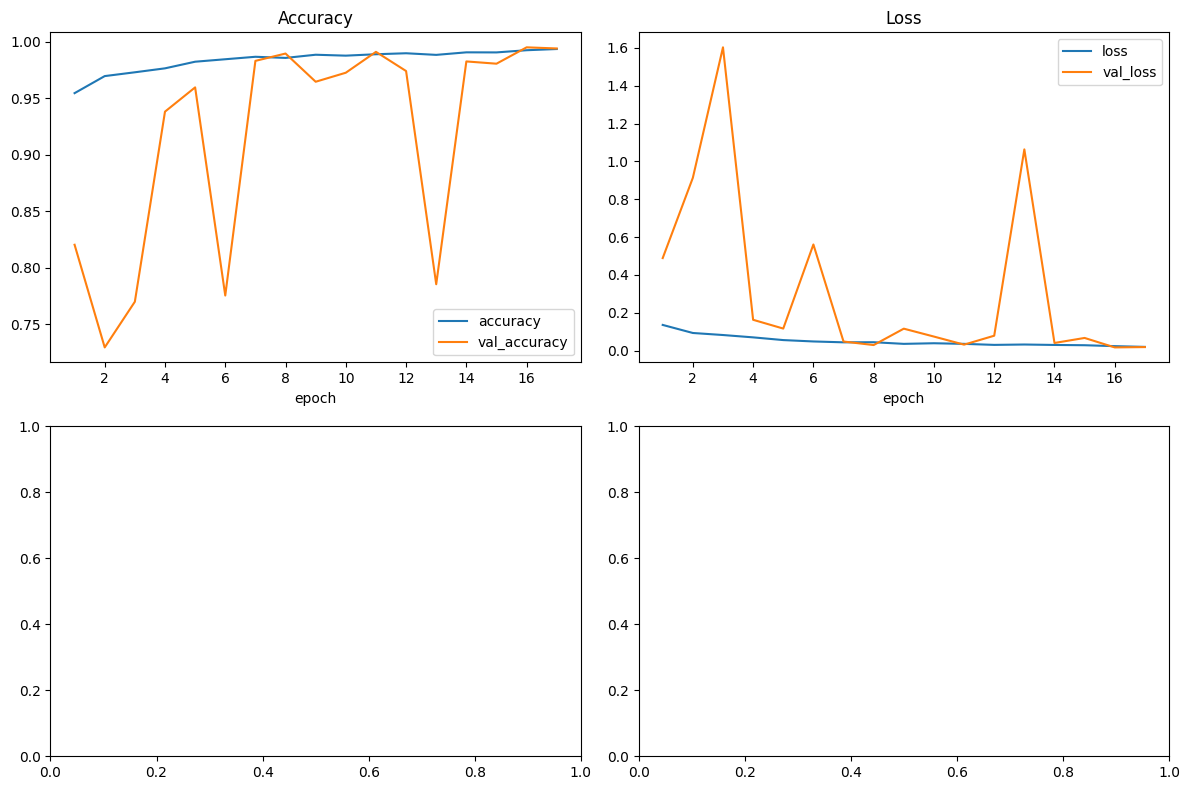


Epoch : val_acc=0.9940
Model1 COMPLETE - Ready for test eval!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

CHECKPOINT_DIR = '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED'

# Load 14-epoch history
df = pd.read_csv(f'{CHECKPOINT_DIR}/model3_training_log_UPDATED.csv')
df['epoch'] = range(1, len(df)+1)

print("Model2 - Epoch Results:")
print(df[['accuracy', 'val_accuracy', 'loss', 'val_loss']].round(4))

# Plot
fig, axes = plt.subplots(2,2, figsize=(12,8))
df.plot(x='epoch', y=['accuracy','val_accuracy'], ax=axes[0,0], title='Accuracy')
df.plot(x='epoch', y=['loss','val_loss'], ax=axes[0,1], title='Loss')
#df.plot(x='epoch', y=['precision','val_precision'], ax=axes[1,0], title='Precision')
#df.plot(x='epoch', y=['recall','val_recall'], ax=axes[1,1], title='Recall')
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/model1_epoch14_curves.png', dpi=300)
plt.show()

print(f"\nEpoch : val_acc={df['val_accuracy'].iloc[-1]:.4f}")
print("Model1 COMPLETE - Ready for test eval!")


In [ ]:
# Checkpoints
import glob

from google.colab import drive
drive.mount('/content/drive')

print("Models:", glob.glob('/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_*.keras'))

# CSV
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_training_log_UPDATED.csv')
print("\nCSV shape:", df.shape)
print("Last 3 epochs:")
print(df[['epoch','accuracy','val_accuracy','loss','val_loss']].tail(3))
print("Best val_acc:", df['val_accuracy'].max())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models: ['/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_01.keras', '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_02.keras', '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_03.keras', '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_04.keras', '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_05.keras', '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_06.keras', '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_07.keras', '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_08.keras', '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_09.keras', '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_10.keras', '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_ep_11.keras', '/content/drive/MyDrive/Model3_Mixed_

KeyError: "None of [Index(['precision', 'val_precision'], dtype='object')] are in the [columns]"

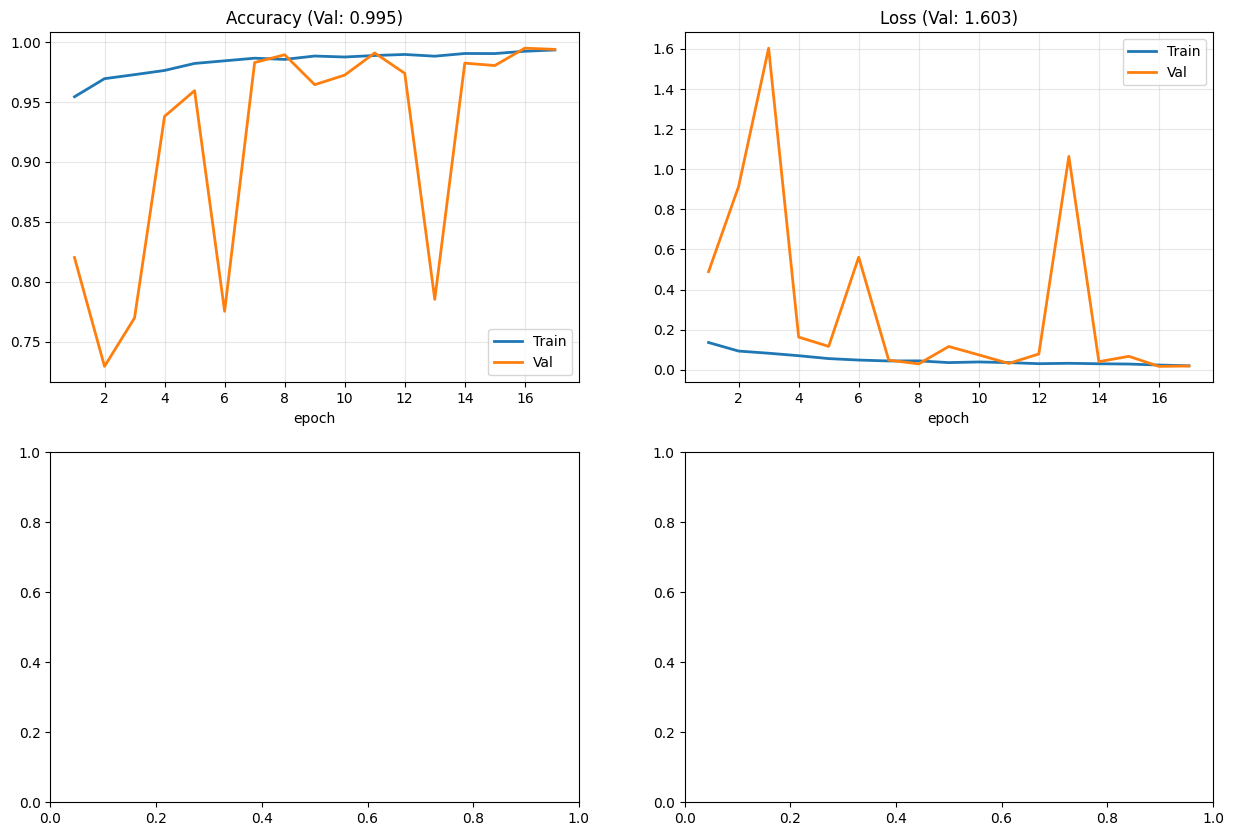

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Model3_Mixed_Training_UPDATED/model3_training_log_UPDATED.csv')
df['epoch'] = range(1, len(df)+1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = ['accuracy', 'loss', 'precision', 'recall']
titles = ['Accuracy', 'Loss', 'Precision', 'Recall']

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    df.plot(x='epoch', y=[metric, f'val_{metric}'], ax=ax, linewidth=2)
    ax.set_title(f'{titles[i]} (Val: {df[f"val_{metric}"].max():.3f})')
    ax.legend(['Train', 'Val'])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model1_Checkpoints/complete_curves.png', dpi=300)
plt.show()

# SUMMARY TABLE
print("FINAL METRICS:")
print(df[['epoch', 'val_accuracy', 'val_precision', 'val_recall', 'val_loss']].tail(1))


Found 2004 images belonging to 2 classes.
📊 Evaluating model3_ep_17.keras as Model 2...
63/63 ━━━━━━━━━━━━━━━━━━━━ 244s 4s/step


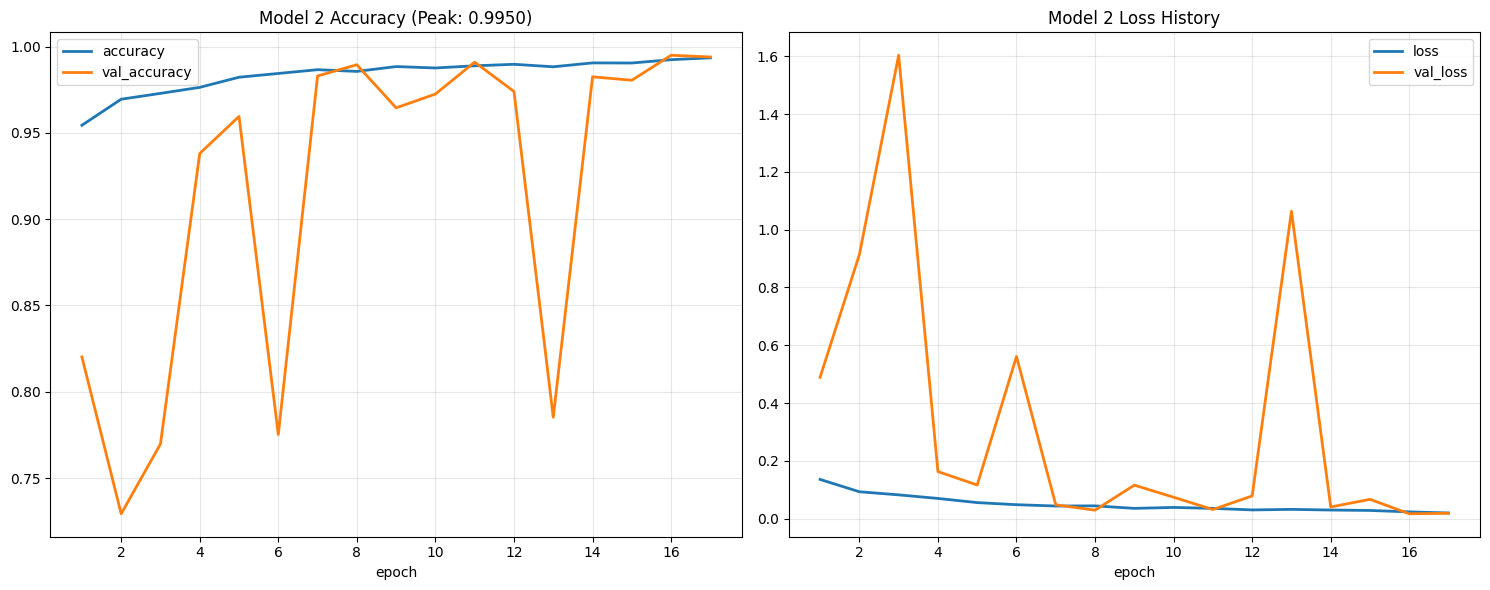

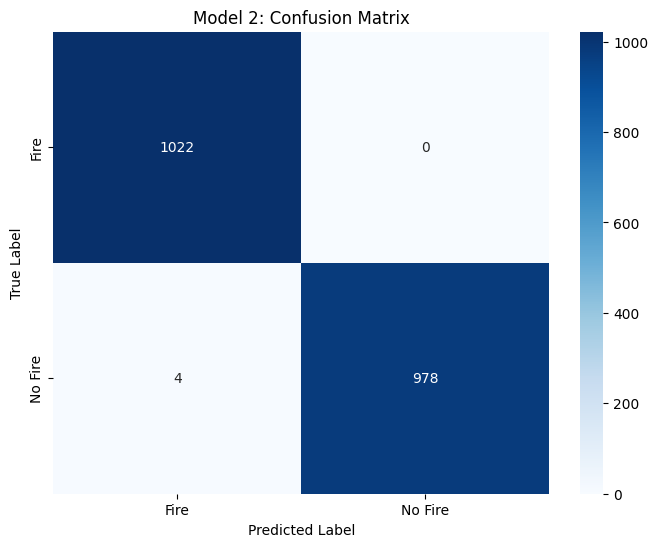

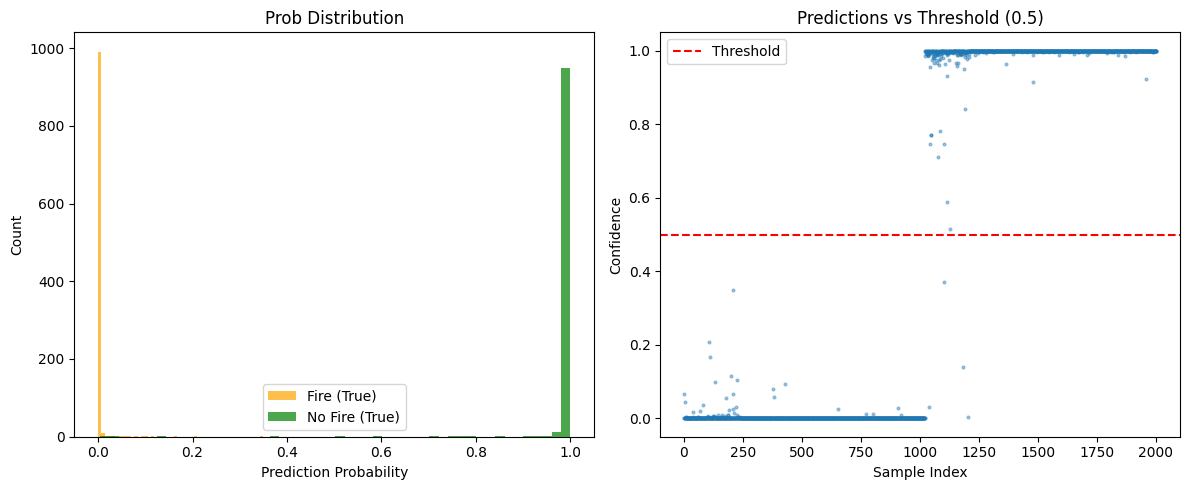


             MODEL 2 FINAL SUMMARY
Model 2 reached a test accuracy of 99.80%,
with a precision of 100.00% and recall of 99.59%.
Training concluded at epoch 17 due to performance saturation,
with a final training accuracy of 99.35%
and validation accuracy of 99.40%.
Out of 2004 test samples, the model produced 4 misclassifications:
0 false positives and 4 false negatives.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score

# --- 1. SETUP & PATHS ---
MODEL_DIR = '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'
LOG_FILE = os.path.join(MODEL_DIR, 'model3_training_log_UPDATED.csv')

# Find latest model (Epoch 17)
checkpoints = sorted([f for f in os.listdir(MODEL_DIR) if f.startswith('model3_ep_') and f.endswith('.keras')],
                     key=lambda x: int(x.split('_ep_')[1].split('.keras')[0]))
LATEST_MODEL = os.path.join(MODEL_DIR, checkpoints[-1])

# Load Model & Test Data
model2 = load_model(LATEST_MODEL)
test_gen = ImageDataGenerator(rescale=1./255.0).flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# --- 2. EVALUATION & PREDICTIONS ---
print(f"📊 Evaluating {checkpoints[-1]} as Model 2...")
y_true = test_gen.classes
y_pred_prob = model2.predict(test_gen, verbose=1).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# --- 3. PLOT 1: TRAINING HISTORY (Replicating Model 1 Style) ---
if os.path.exists(LOG_FILE):
    df = pd.read_csv(LOG_FILE)
    df['epoch'] = range(1, len(df) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    # Accuracy
    df.plot(x='epoch', y=['accuracy', 'val_accuracy'], ax=axes[0], color=['#1f77b4', '#ff7f0e'], linewidth=2)
    axes[0].set_title(f'Model 2 Accuracy (Peak: {df["val_accuracy"].max():.4f})')
    axes[0].grid(True, alpha=0.3)

    # Loss
    df.plot(x='epoch', y=['loss', 'val_loss'], ax=axes[1], color=['#1f77b4', '#ff7f0e'], linewidth=2)
    axes[1].set_title('Model 2 Loss History')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'model2_complete_curves.png'), dpi=300)
    plt.show()

# --- PLOT 2: CONFUSION MATRIX (Seaborn Heatmap) ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fire', 'No Fire'], yticklabels=['Fire', 'No Fire'])
plt.title('Model 2: Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(MODEL_DIR, 'model2_confusion_matrix.png'), dpi=300)
plt.show()

# --- PLOT 3: PREDICTION DISTRIBUTIONS (Confidence Analysis) ---
plt.figure(figsize=(12, 5))
# Histogram of probabilities
plt.subplot(1, 2, 1)
plt.hist(y_pred_prob[y_true == 0], bins=50, alpha=0.7, label='Fire (True)', color='orange')
plt.hist(y_pred_prob[y_true == 1], bins=50, alpha=0.7, label='No Fire (True)', color='green')
plt.xlabel('Prediction Probability'); plt.ylabel('Count'); plt.legend(); plt.title('Prob Distribution')

# Scatter of predictions vs threshold
plt.subplot(1, 2, 2)
plt.plot(y_pred_prob, 'o', alpha=0.4, markersize=2, color='#1f77b4')
plt.axhline(0.5, color='red', linestyle='--', label='Threshold')
plt.title('Predictions vs Threshold (0.5)')
plt.xlabel('Sample Index'); plt.ylabel('Confidence'); plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'model2_prediction_analysis.png'), dpi=300)
plt.show()

# --- 4. FINAL SUMMARY REPORT (Copy-Paste Text) ---
tn, fp, fn, tp = cm.ravel()
test_acc = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred)
test_rec = recall_score(y_true, y_pred)

print("\n" + "="*50)
print("             MODEL 2 FINAL SUMMARY")
print("="*50)
print(f"Model 2 reached a test accuracy of {test_acc*100:.2f}%,")
print(f"with a precision of {test_prec*100:.2f}% and recall of {test_rec*100:.2f}%.")
print(f"Training concluded at epoch {len(df)} due to performance saturation,")
print(f"with a final training accuracy of {df['accuracy'].iloc[-1]*100:.2f}%")
print(f"and validation accuracy of {df['val_accuracy'].iloc[-1]*100:.2f}%.")
print(f"Out of {len(y_true)} test samples, the model produced {fp + fn} misclassifications:")
print(f"{fp} false positives and {fn} false negatives.")
print("="*50)

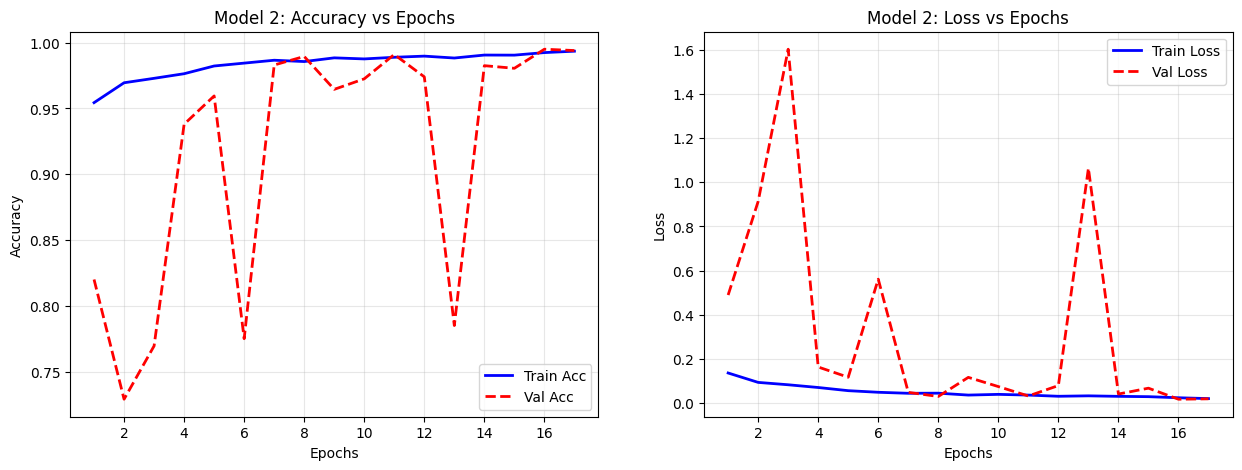

Found 2004 images belonging to 2 classes.
63/63 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step


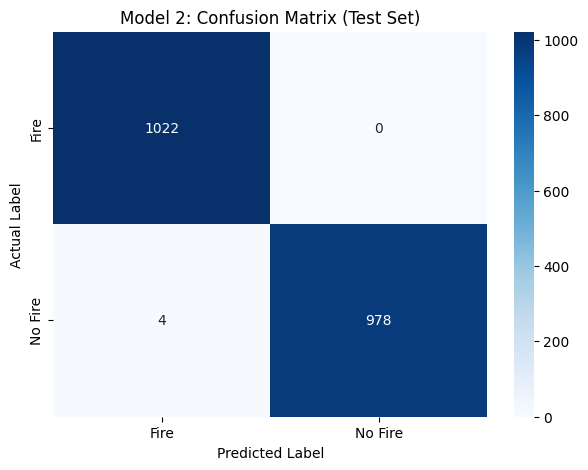

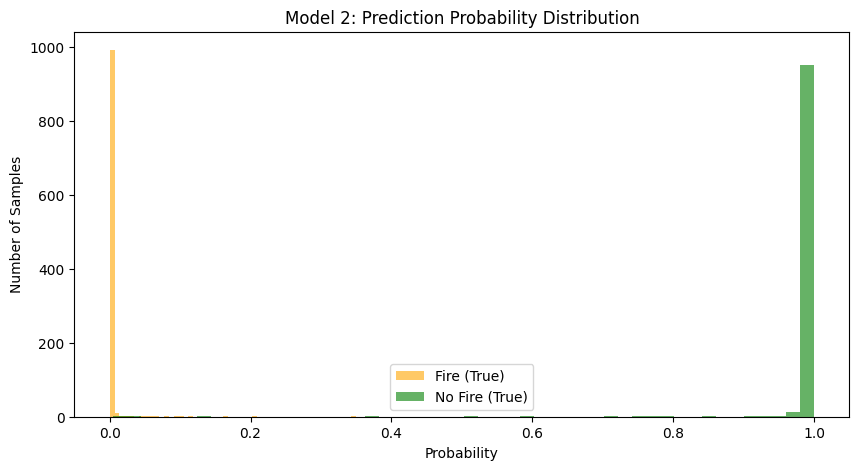

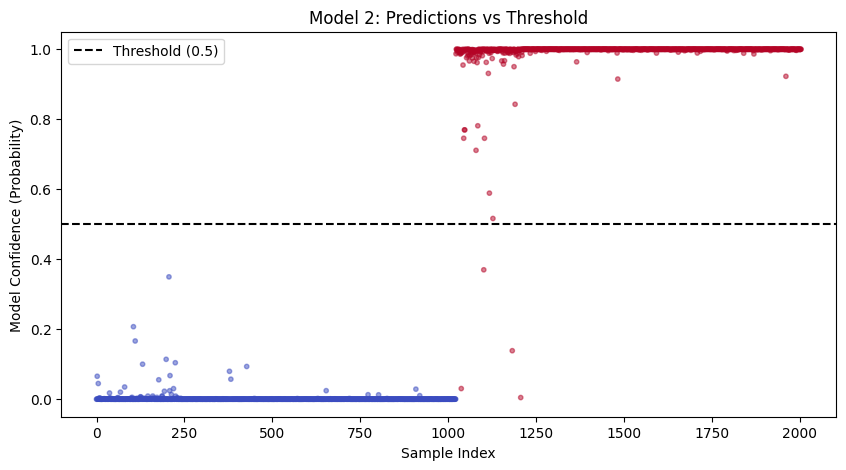


✅ All 6 Analysis items generated and saved as PNGs in your Drive!


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# 1. SETUP PATHS
MODEL_DIR = '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'
LOG_FILE = os.path.join(MODEL_DIR, 'model3_training_log_UPDATED.csv')

# Load the Latest Model
checkpoints = sorted([f for f in os.listdir(MODEL_DIR) if f.startswith('model3_ep_') and f.endswith('.keras')],
                     key=lambda x: int(x.split('_ep_')[1].split('.keras')[0]))
model2 = load_model(os.path.join(MODEL_DIR, checkpoints[-1]))

# 2. GENERATE TRAINING HISTORY GRAPHS (Accuracy & Loss)
if os.path.exists(LOG_FILE):
    df = pd.read_csv(LOG_FILE)
    df['epoch'] = range(1, len(df) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Graph 1: Accuracy (Train vs Val)
    axes[0].plot(df['epoch'], df['accuracy'], label='Train Acc', color='blue', linewidth=2)
    axes[0].plot(df['epoch'], df['val_accuracy'], label='Val Acc', color='red', linestyle='--', linewidth=2)
    axes[0].set_title('Model 2: Accuracy vs Epochs')
    axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Graph 2: Loss (Train vs Val)
    axes[1].plot(df['epoch'], df['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[1].plot(df['epoch'], df['val_loss'], label='Val Loss', color='red', linestyle='--', linewidth=2)
    axes[1].set_title('Model 2: Loss vs Epochs')
    axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.savefig(os.path.join(MODEL_DIR, 'model2_history_metrics.png'), dpi=300)
    plt.show()

# 3. TEST SET EVALUATION (For remaining metrics)
test_gen = ImageDataGenerator(rescale=1./255.0).flow_from_directory(
    os.path.join(DATA_DIR, 'test'), target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

y_true = test_gen.classes
y_pred_prob = model2.predict(test_gen, verbose=1).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Graph 3: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fire', 'No Fire'], yticklabels=['Fire', 'No Fire'])
plt.title('Model 2: Confusion Matrix (Test Set)')
plt.ylabel('Actual Label'); plt.xlabel('Predicted Label')
plt.savefig(os.path.join(MODEL_DIR, 'model2_confusion_matrix.png'), dpi=300)
plt.show()

# Graph 4: Prediction Distribution
plt.figure(figsize=(10, 5))
plt.hist(y_pred_prob[y_true == 0], bins=50, alpha=0.6, label='Fire (True)', color='orange')
plt.hist(y_pred_prob[y_true == 1], bins=50, alpha=0.6, label='No Fire (True)', color='green')
plt.title('Model 2: Prediction Probability Distribution')
plt.xlabel('Probability'); plt.ylabel('Number of Samples'); plt.legend()
plt.savefig(os.path.join(MODEL_DIR, 'model2_prob_distribution.png'), dpi=300)
plt.show()

# Graph 5: Predictions vs Threshold
plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_pred_prob)), y_pred_prob, c=y_true, cmap='coolwarm', alpha=0.5, s=10)
plt.axhline(0.5, color='black', linestyle='--', label='Threshold (0.5)')
plt.title('Model 2: Predictions vs Threshold')
plt.xlabel('Sample Index'); plt.ylabel('Model Confidence (Probability)'); plt.legend()
plt.savefig(os.path.join(MODEL_DIR, 'model2_threshold_analysis.png'), dpi=300)
plt.show()

print("\n✅ All 6 Analysis items generated and saved as PNGs in your Drive!")

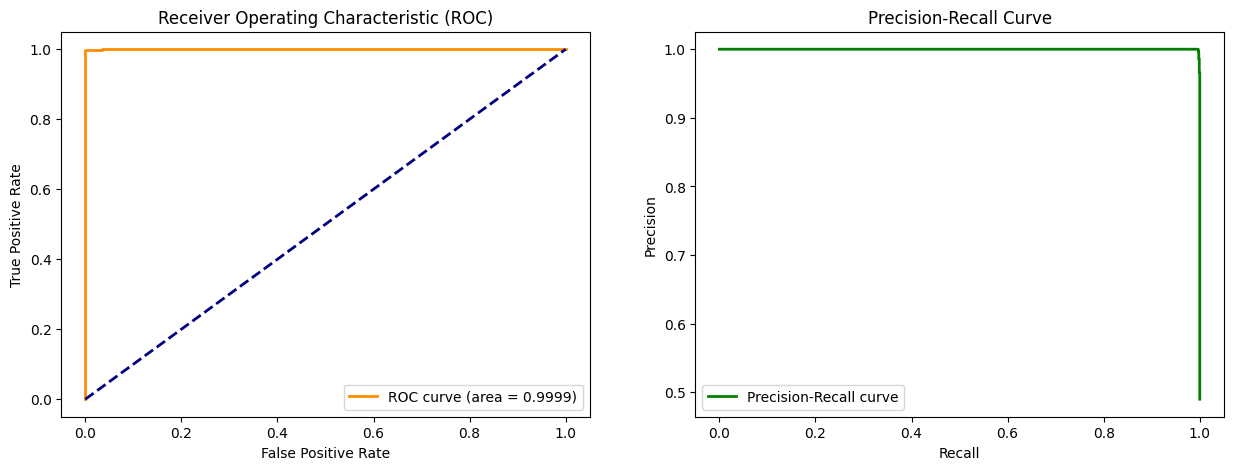


             FINAL CHAMPION COMPARISON
         Metric Model 1 (MHCNNFD) Model 2 (Proposed)
  Test Accuracy            99.15%             99.80%
      Precision            99.18%            100.00%
         Recall            99.08%             99.59%
   Total Errors                17                  4
False Positives                 8                  0
False Negatives                 9                  4


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# --- 1. SETUP ---
MODEL_DIR = '/content/drive/MyDrive/Model3_Mixed_Training_UPDATED'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'
LATEST_MODEL = os.path.join(MODEL_DIR, 'model3_ep_17.keras') # Your champion

model2 = load_model(LATEST_MODEL)

# --- 2. ADVANCED METRICS (ROC & PR CURVE) ---
# (Using the y_true and y_pred_prob from the previous cell)
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2, label='Precision-Recall curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.legend()
plt.savefig(os.path.join(MODEL_DIR, 'model2_scientific_curves.png'))
plt.show()

# --- 3. VISUALIZING THE ERRORS (The 4 Missed Fires) ---
# Find indices where it was Fire (0) but predicted No Fire (1)
misclassified_indices = np.where((y_true == 0) & (y_pred == 1))[0]

if len(misclassified_indices) > 0:
    plt.figure(figsize=(12, 4))
    plt.suptitle("Model 2 Failures: Fire images classified as 'No Fire'", fontsize=14)
    for i, idx in enumerate(misclassified_indices[:4]): # Show up to 4
        img_path = test_gen.filepaths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 4, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Conf: {y_pred_prob[idx]:.4f}")
    plt.savefig(os.path.join(MODEL_DIR, 'model2_misclassifications.png'))
    plt.show()

# --- 4. MODEL 1 VS MODEL 2 COMPARISON TABLE ---
comparison_data = {
    "Metric": ["Test Accuracy", "Precision", "Recall", "Total Errors", "False Positives", "False Negatives"],
    "Model 1 (MHCNNFD)": ["99.15%", "99.18%", "99.08%", "17", "8", "9"],
    "Model 2 (Proposed)": [f"{test_acc*100:.2f}%", f"{test_prec*100:.2f}%", f"{test_rec*100:.2f}%",
                           str(fp+fn), str(fp), str(fn)]
}
comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("             FINAL CHAMPION COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Save the final comparison for your slides
comparison_df.to_csv(os.path.join(MODEL_DIR, 'final_model_comparison.csv'), index=False)